In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tqdm import tqdm
import glob
import os

In [26]:
# --- 1. Configuration ---
RAW_DATA_DIR = "" 
PCA_COMPONENTS = 50
EPOCHS = 50 
BATCH_SIZE = 32
USE_PCA = True
USE_MAGNITUDE = True
VALID_ACTIVITIES = ['sitting', 'walking', 'standing', 'sleeping', 'falling']

train_sessions_files = [
    'esp32_csi_falling_20250727_131141.csv',
    'esp32_csi_sitting_20250727_155647.csv',
    'esp32_csi_sleeping_20250727_161957.csv',
    'esp32_csi_standing_20250727_153848.csv',
    'esp32_csi_walking_20250727_150913.csv',
    'esp32_csi_falling_20250727_164609.csv',
    'esp32_csi_sitting_20250728_131136.csv',
    'esp32_csi_sleeping_20250728_120628.csv',
    'esp32_csi_standing_20250728_134638.csv',
    'esp32_csi_walking_20250728_143333.csv'
]

val_sessions_files = [
    'esp32_csi_falling_20250728_113607.csv',
    'esp32_csi_sitting_20250728_132048.csv',
    'esp32_csi_sleeping_20250728_122306.csv',
    'esp32_csi_standing_20250728_142148.csv',
    'esp32_csi_walking_20250728_150304.csv'
]

In [27]:
# Check if files actually exist in current directory
import os
print("🔍 Checking file availability in current directory:")

# List all CSV files in current directory
current_files = [f for f in os.listdir('.') if f.endswith('.csv') and f.startswith('esp32_csi_')]
print(f"Available CSV files: {len(current_files)}")

if current_files:
    print("Sample files found:")
    for file in sorted(current_files)[:10]:
        print(f"  - {file}")
else:
    print("❌ No ESP32 CSI files found in current directory!")

# Check if specified train files exist
print(f"\n📊 Training files status:")
missing_train = []
for file in train_sessions_files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} - NOT FOUND")
        missing_train.append(file)

print(f"\n📊 Validation files status:")
missing_val = []
for file in val_sessions_files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} - NOT FOUND")
        missing_val.append(file)

if missing_train or missing_val:
    print(f"\n⚠️  Missing files detected!")
    print(f"This will cause errors in data loading.")
    print(f"Consider updating the file lists to match available files.")

🔍 Checking file availability in current directory:
Available CSV files: 167
Sample files found:
  - esp32_csi_chair_20250707_155758.csv
  - esp32_csi_empty_20250707_125659.csv
  - esp32_csi_empty_20250707_163140.csv
  - esp32_csi_empty_20250708_145835.csv
  - esp32_csi_empty_20250709_115618.csv
  - esp32_csi_empty_20250709_115841.csv
  - esp32_csi_empty_20250709_131936.csv
  - esp32_csi_empty_20250709_132316.csv
  - esp32_csi_empty_20250709_132548.csv
  - esp32_csi_empty_20250709_133206.csv

📊 Training files status:
✅ esp32_csi_falling_20250727_131141.csv
✅ esp32_csi_sitting_20250727_155647.csv
✅ esp32_csi_sleeping_20250727_161957.csv
✅ esp32_csi_standing_20250727_153848.csv
✅ esp32_csi_walking_20250727_150913.csv
✅ esp32_csi_falling_20250727_164609.csv
✅ esp32_csi_sitting_20250728_131136.csv
✅ esp32_csi_sleeping_20250728_120628.csv
✅ esp32_csi_standing_20250728_134638.csv
✅ esp32_csi_walking_20250728_143333.csv

📊 Validation files status:
✅ esp32_csi_falling_20250728_113607.csv
✅ esp3

In [28]:
# Auto-generate proper session splits from available files
from collections import defaultdict
from datetime import datetime
import re

def create_automatic_session_split():
    """Automatically create train/val splits from available files with temporal ordering"""
    
    # Get all ESP32 CSI files
    all_files = [f for f in os.listdir('.') if f.endswith('.csv') and f.startswith('esp32_csi_')]
    
    if not all_files:
        print("❌ No ESP32 CSI files found!")
        return [], []
    
    # Parse file information
    file_info = []
    pattern = r'esp32_csi_(\w+)_(\d{8})_(\d{6})\.csv'
    
    for filename in all_files:
        match = re.match(pattern, filename)
        if match:
            activity, date_str, time_str = match.groups()
            if activity in VALID_ACTIVITIES:
                try:
                    dt = datetime.strptime(f"{date_str}_{time_str}", "%Y%m%d_%H%M%S")
                    file_info.append((filename, activity, dt))
                except:
                    continue
    
    if not file_info:
        print("❌ No valid files found matching the pattern!")
        return [], []
    
    # Group by activity
    activity_groups = defaultdict(list)
    for filename, activity, dt in file_info:
        activity_groups[activity].append((filename, dt))
    
    # Sort each activity by timestamp and split temporally
    train_files = []
    val_files = []
    
    print(f"🎯 Creating temporal session splits:")
    print(f"{'Activity':<10} {'Total':<6} {'Train':<6} {'Valid':<6}")
    print("-" * 35)
    
    for activity, files in activity_groups.items():
        # Sort by datetime
        files.sort(key=lambda x: x[1])
        
        n_files = len(files)
        if n_files < 2:
            print(f"{activity:<10} {n_files:<6} {'SKIP':<6} {'SKIP':<6}")
            continue
        
        # Use 75% for training (earlier sessions), 25% for validation (later sessions)
        split_idx = max(1, int(n_files * 0.75))
        
        train_activity = [f[0] for f in files[:split_idx]]
        val_activity = [f[0] for f in files[split_idx:]]
        
        train_files.extend(train_activity)
        val_files.extend(val_activity)
        
        print(f"{activity:<10} {n_files:<6} {len(train_activity):<6} {len(val_activity):<6}")
    
    print(f"\n✅ Generated splits:")
    print(f"Training files: {len(train_files)}")
    print(f"Validation files: {len(val_files)}")
    
    return train_files, val_files

# Generate new splits
auto_train_files, auto_val_files = create_automatic_session_split()

# Update the file lists if auto-generation was successful
if auto_train_files and auto_val_files:
    print(f"\n🔄 Updating file lists to use available files...")
    train_sessions_files = auto_train_files
    val_sessions_files = auto_val_files
    
    print(f"✅ Updated training files ({len(train_sessions_files)}):")
    for f in train_sessions_files:
        print(f"  - {f}")
    
    print(f"✅ Updated validation files ({len(val_sessions_files)}):")
    for f in val_sessions_files:
        print(f"  - {f}")
else:
    print("⚠️  Could not auto-generate splits. Using original file lists.")

🎯 Creating temporal session splits:
Activity   Total  Train  Valid 
-----------------------------------
sitting    32     24     8     
sleeping   30     22     8     
walking    32     24     8     
falling    30     22     8     
standing   31     23     8     

✅ Generated splits:
Training files: 115
Validation files: 40

🔄 Updating file lists to use available files...
✅ Updated training files (115):
  - esp32_csi_sitting_20250707_160029.csv
  - esp32_csi_sitting_20250707_162824.csv
  - esp32_csi_sitting_20250727_155647.csv
  - esp32_csi_sitting_20250727_155903.csv
  - esp32_csi_sitting_20250727_160108.csv
  - esp32_csi_sitting_20250727_160311.csv
  - esp32_csi_sitting_20250727_160513.csv
  - esp32_csi_sitting_20250727_160718.csv
  - esp32_csi_sitting_20250727_160929.csv
  - esp32_csi_sitting_20250727_161310.csv
  - esp32_csi_sitting_20250727_161517.csv
  - esp32_csi_sitting_20250727_161725.csv
  - esp32_csi_sitting_20250728_125533.csv
  - esp32_csi_sitting_20250728_125737.csv
  - e

In [29]:
# --- 2. Data Loading and Cleaning Function ---
def load_and_clean_sessions(file_list, data_dir):
    """Loads, concatenates, and cleans a specific list of session files."""
    df_list = []
    for filename in tqdm(file_list, desc=f"Loading files for set"):
        file_path = os.path.join(data_dir, filename)
        if not os.path.exists(file_path):
            print(f"[Warning] File not found: {filename}. Skipping.")
            continue
        try:
            activity_label = filename.split('_')[2]
            if activity_label in VALID_ACTIVITIES:
                temp_df = pd.read_csv(file_path)
                temp_df['activity'] = activity_label
                temp_df['session'] = filename
                df_list.append(temp_df)
        except Exception as e:
            print(f"Could not process {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    master_df = pd.concat(df_list, ignore_index=True)
    
    # Cleaning Steps
    null_subcarriers = list(range(27, 37))
    cleaned = master_df[~master_df['subcarrier_index'].isin(null_subcarriers)]
    
    magnitude_sum = cleaned.groupby(['session', 'timestamp'])['magnitude'].sum()
    dropout_indices = magnitude_sum[magnitude_sum == 0].index
    cleaned = cleaned.set_index(['session', 'timestamp']).drop(index=dropout_indices).reset_index()
    
    return cleaned

In [30]:
# --- 3. Create Training and Validation DataFrames ---
print("--- Creating Training DataFrame ---")
train_df = load_and_clean_sessions(train_sessions_files, RAW_DATA_DIR)

print("\n--- Creating Validation DataFrame ---")
val_df = load_and_clean_sessions(val_sessions_files, RAW_DATA_DIR)

if train_df.empty or val_df.empty:
    print("\n[ERROR] Training or validation dataframe is empty. Please check your filenames and data directory.")

--- Creating Training DataFrame ---


Loading files for set: 100%|██████████| 115/115 [00:01<00:00, 57.60it/s]



--- Creating Validation DataFrame ---


Loading files for set: 100%|██████████| 40/40 [00:00<00:00, 55.67it/s]


In [31]:
# --- 4. Prepare Data for Model (Timestamp Grouping) ---
def prepare_model_input(df):
    """Processes a dataframe into model-ready features (X) and labels (y)."""
    df['instance_id'] = df['session'] + '_' + df['timestamp'].astype(str)
    data, labels = [], []
    grouped = df.groupby("instance_id")
    for _, group in tqdm(grouped, desc="Processing Timestamps"):
        if USE_MAGNITUDE:
            features = group["magnitude"].values
        else:
            features = group[["I", "Q"]].values.flatten()
        
        if len(features) > 0:
            data.append(features)
            labels.append(group["activity"].iloc[0])
            
    return data, np.array(labels)

print("\n--- Preparing Training Data ---")
X_train_list, y_train_raw = prepare_model_input(train_df)
print("\n--- Preparing Validation Data ---")
X_val_list, y_val_raw = prepare_model_input(val_df)


--- Preparing Training Data ---


Processing Timestamps: 100%|██████████| 155237/155237 [00:04<00:00, 34990.52it/s]



--- Preparing Validation Data ---


Processing Timestamps: 100%|██████████| 53656/53656 [00:01<00:00, 36135.81it/s]


In [32]:
# --- 5. Pad Data and Apply PCA ---
print("\nPadding data to ensure consistent feature length...")
# Find the maximum feature length across both train and validation sets before splitting
max_len = max(max(len(x) for x in X_train_list), max(len(x) for x in X_val_list))

X_train_padded = tf.keras.preprocessing.sequence.pad_sequences(X_train_list, padding='post', maxlen=max_len, dtype='float32')
X_val_padded = tf.keras.preprocessing.sequence.pad_sequences(X_val_list, padding='post', maxlen=max_len, dtype='float32')

print(f"Padded training data shape: {X_train_padded.shape}")
print(f"Padded validation data shape: {X_val_padded.shape}")

# --- Encode Labels and Apply PCA ---
print("\nEncoding labels and applying PCA...")
le = LabelEncoder()
# Fit on all possible labels to ensure consistency
all_labels = np.concatenate([y_train_raw, y_val_raw])
le.fit(all_labels)
class_names = list(le.classes_)

y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
print(f"Label mapping: { {i: label for i, label in enumerate(class_names)} }")

X_train, X_val = X_train_padded, X_val_padded
if USE_PCA:
    n_components = min(PCA_COMPONENTS, X_train.shape[1])
    pca = PCA(n_components=n_components)
    X_train = pca.fit_transform(X_train)
    X_val = pca.transform(X_val)
    print(f"Shape after PCA (X_train): {X_train.shape}")

input_shape = (X_train.shape[1],)


Padding data to ensure consistent feature length...
Padded training data shape: (155237, 117)
Padded validation data shape: (53656, 117)

Encoding labels and applying PCA...
Label mapping: {0: 'falling', 1: 'sitting', 2: 'sleeping', 3: 'standing', 4: 'walking'}
Shape after PCA (X_train): (155237, 50)


In [33]:
# --- 6. Model Definition (TensorFlow/Keras) ---
def build_cnn_lstm(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape((input_shape[0], 1)),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn_lstm(input_shape, num_classes=len(class_names))
model.summary()

2025-08-09 00:49:29.255939: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-08-09 00:49:29.256021: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-08-09 00:49:29.256027: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-08-09 00:49:29.256083: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-09 00:49:29.256098: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,765 (147.52 KB)

 Trainable params: 37,765 (147.52 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# --- 7. Train the Model ---
print("\nStarting model training...")
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=2
)


Starting model training...
Epoch 1/50


2025-08-09 00:49:34.229476: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


4852/4852 - 71s - 15ms/step - accuracy: 0.6069 - loss: 0.8971 - val_accuracy: 0.5237 - val_loss: 1.6109
Epoch 2/50
4852/4852 - 67s - 14ms/step - accuracy: 0.7122 - loss: 0.6965 - val_accuracy: 0.5182 - val_loss: 1.6277
Epoch 3/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7478 - loss: 0.6286 - val_accuracy: 0.5399 - val_loss: 1.5919
Epoch 4/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7616 - loss: 0.5969 - val_accuracy: 0.5477 - val_loss: 1.6250
Epoch 5/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7685 - loss: 0.5799 - val_accuracy: 0.5667 - val_loss: 1.5970
Epoch 6/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7746 - loss: 0.5704 - val_accuracy: 0.5609 - val_loss: 1.8869
Epoch 7/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7793 - loss: 0.5620 - val_accuracy: 0.5447 - val_loss: 1.7085
Epoch 8/50
4852/4852 - 66s - 14ms/step - accuracy: 0.7774 - loss: 0.5689 - val_accuracy: 0.5187 - val_loss: 1.8552
Epoch 9/50
4852/4852 - 71s - 15ms/step - accuracy: 0.7723 - loss: 0.5846 - val_accuracy: 0.


Evaluating model performance on unseen validation sessions...


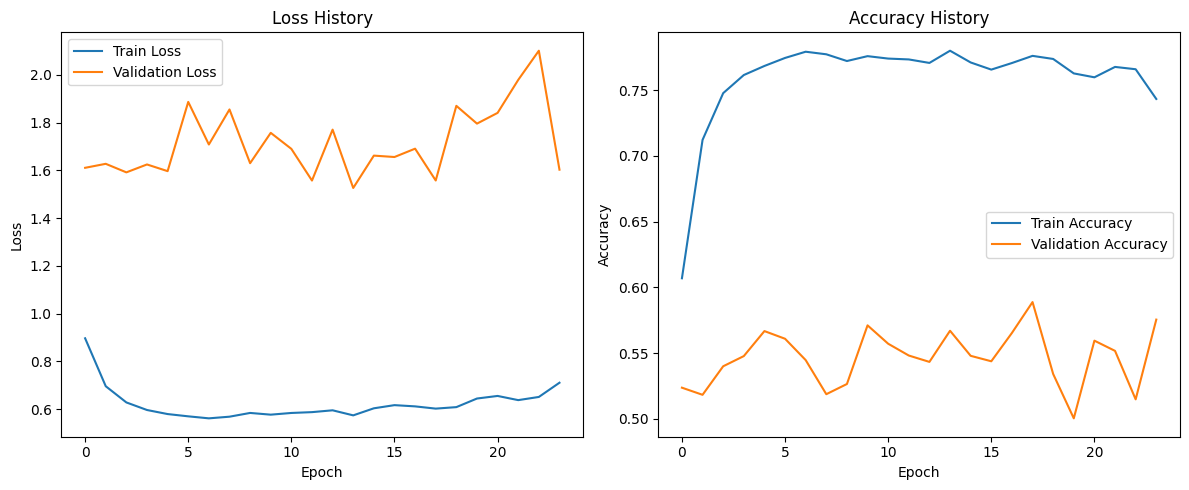

1677/1677 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


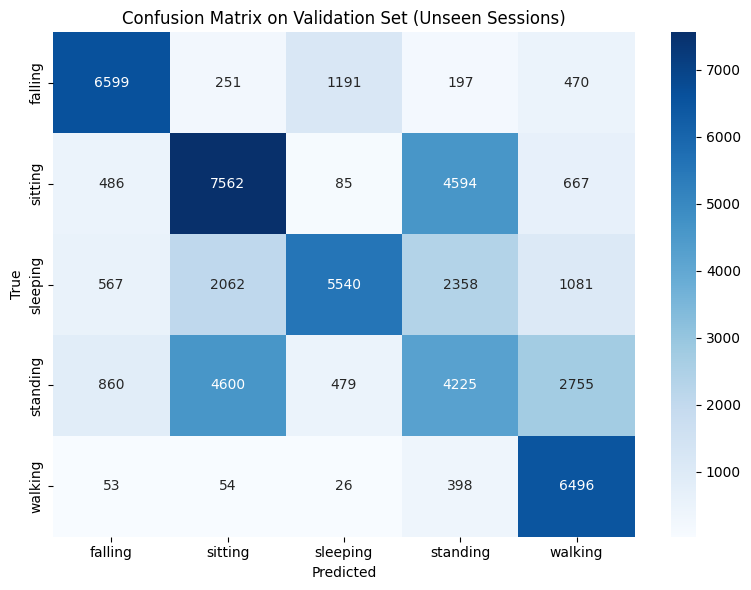


Classification Report on Validation Set (Unseen Sessions):

              precision    recall  f1-score   support

     falling       0.77      0.76      0.76      8708
     sitting       0.52      0.56      0.54     13394
    sleeping       0.76      0.48      0.59     11608
    standing       0.36      0.33      0.34     12919
     walking       0.57      0.92      0.70      7027

    accuracy                           0.57     53656
   macro avg       0.59      0.61      0.59     53656
weighted avg       0.58      0.57      0.56     53656



In [35]:
# --- 8. Evaluate the Model ---
print("\nEvaluating model performance on unseen validation sessions...")

# --- Plot training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion Matrix and Report on the Validation Set ---
preds = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Validation Set (Unseen Sessions)")
plt.tight_layout()
plt.show()

print("\nClassification Report on Validation Set (Unseen Sessions):\n")
print(classification_report(y_val, preds, target_names=class_names))